In [1]:
!pip install librosa -q

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.signal as signal

In [2]:
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving my_voice.m4a to my_voice.m4a


convert to WAV

In [4]:
import os

input_file = list(uploaded.keys())[0]

# Output file name
output_file = "converted_audio.wav"

# Convert using ffmpeg
!ffmpeg -i "$input_file" -ac 1 -ar 16000 "$output_file"

print("Converted to WAV:", output_file)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

lad wav for processing

In [5]:
import librosa

y, sr = librosa.load(output_file, sr=None)
print("Sampling Rate:", sr)

Sampling Rate: 16000


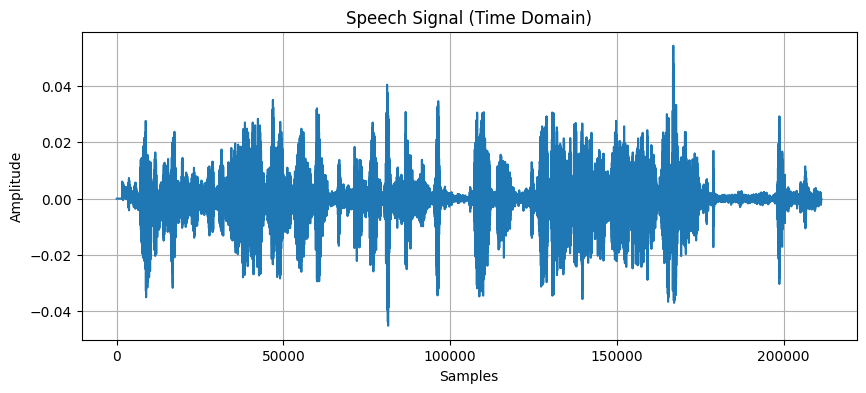

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Speech Signal (Time Domain)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

FFT → Pitch, Harmonics, Formants

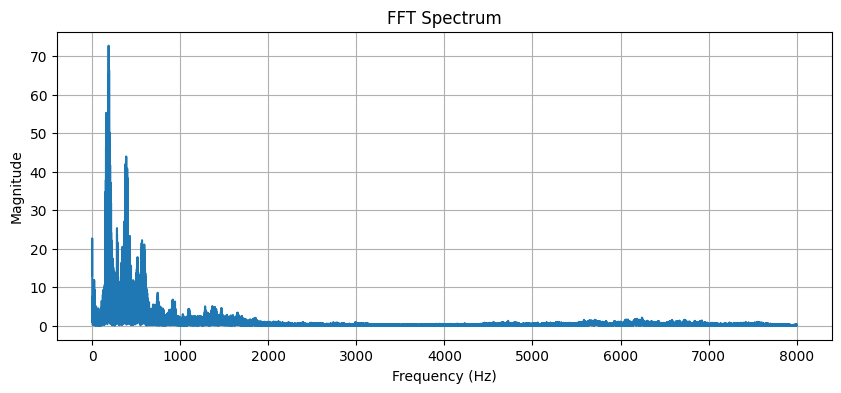

In [10]:
import numpy as np

Y = np.fft.fft(y)
freqs = np.fft.fftfreq(len(Y), 1/sr)

plt.figure(figsize=(10,4))
plt.plot(freqs[:len(freqs)//2], np.abs(Y[:len(Y)//2]))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

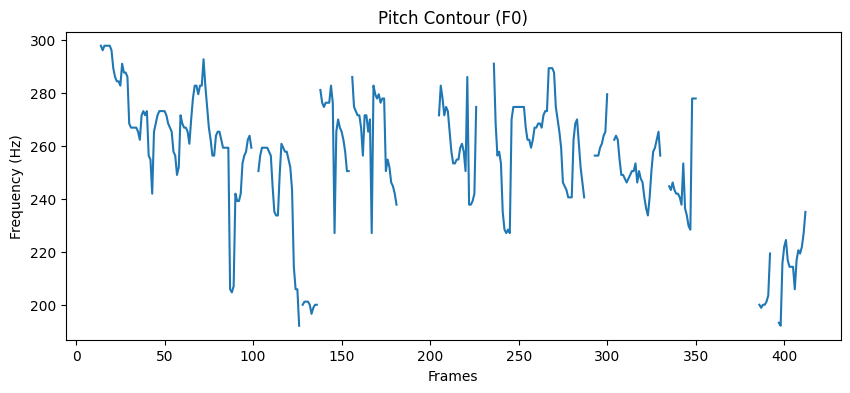

In [11]:
f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=50, fmax=300)

plt.figure(figsize=(10,4))
plt.plot(f0)
plt.title("Pitch Contour (F0)")
plt.xlabel("Frames")
plt.ylabel("Frequency (Hz)")
plt.show()

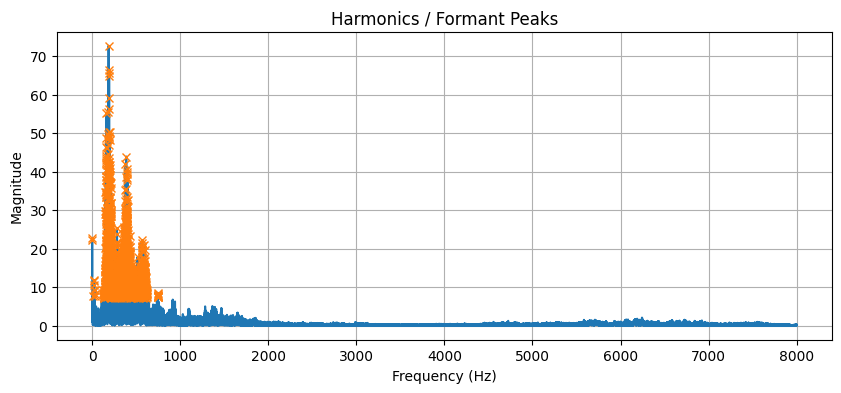

Estimated Frequencies: [ 0.68154389  0.83299808  6.05816788 18.40168493 21.05213337]


In [12]:
from scipy.signal import find_peaks

spectrum = np.abs(Y[:len(Y)//2])
freqs_half = freqs[:len(freqs)//2]

peaks, _ = find_peaks(spectrum, height=max(spectrum)*0.1)

plt.figure(figsize=(10,4))
plt.plot(freqs_half, spectrum)
plt.plot(freqs_half[peaks], spectrum[peaks], "x")
plt.title("Harmonics / Formant Peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

print("Estimated Frequencies:", freqs_half[peaks[:5]])

STFT → Spectrogram

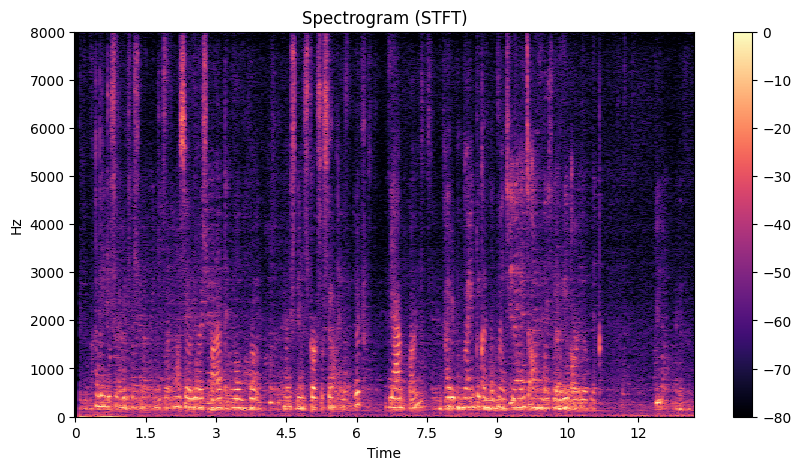

In [13]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram (STFT)")
plt.show()

Narrowband vs Wideband Spectrogram

Narrowband

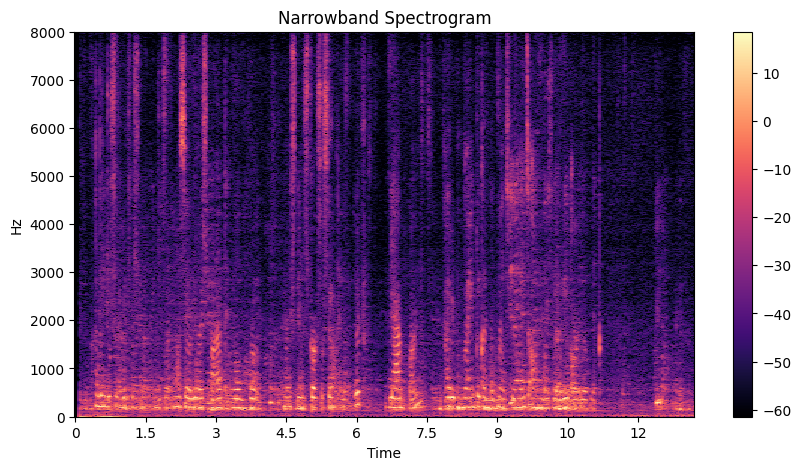

In [14]:
D_narrow = librosa.stft(y, n_fft=2048)
S_narrow = librosa.amplitude_to_db(np.abs(D_narrow))

plt.figure(figsize=(10,5))
librosa.display.specshow(S_narrow, sr=sr, x_axis='time', y_axis='hz')
plt.title("Narrowband Spectrogram")
plt.colorbar()
plt.show()

wideband

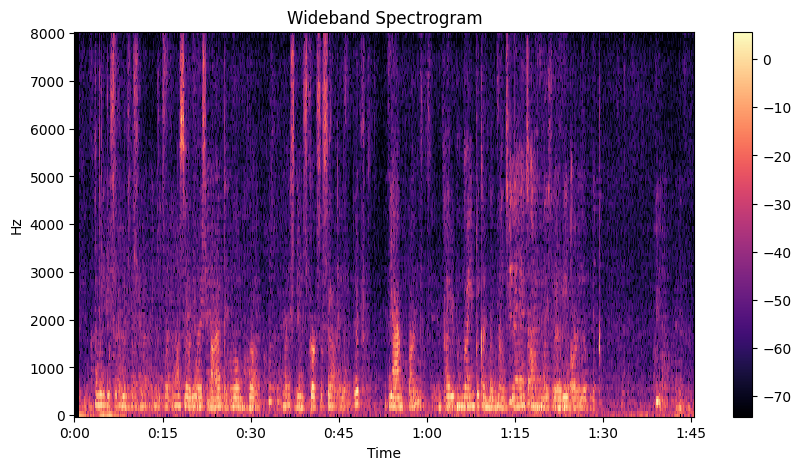

In [15]:
D_wide = librosa.stft(y, n_fft=256)
S_wide = librosa.amplitude_to_db(np.abs(D_wide))

plt.figure(figsize=(10,5))
librosa.display.specshow(S_wide, sr=sr, x_axis='time', y_axis='hz')
plt.title("Wideband Spectrogram")
plt.colorbar()
plt.show()